In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("EDA environment ready.")

EDA environment ready.


In [2]:
demand_path = "../data/processed/hourly_zone_demand_2025_01.parquet"

demand = pd.read_parquet(demand_path)

print("Dataset shape:", demand.shape)

demand.head()

Dataset shape: (195672, 13)


,datetime,date,hour,day_of_week,day_of_week_num,day_of_month,month,is_weekend,PULocationID,Borough,Zone,service_zone,demand
0,2025-01-01,2025-01-01,0,Wednesday,2,1,1,False,1,EWR,Newark Airport,EWR,0
1,2025-01-01,2025-01-01,0,Wednesday,2,1,1,False,2,Queens,Jamaica Bay,Boro Zone,0
2,2025-01-01,2025-01-01,0,Wednesday,2,1,1,False,3,Bronx,Allerton/Pelham Gardens,Boro Zone,74
3,2025-01-01,2025-01-01,0,Wednesday,2,1,1,False,4,Manhattan,Alphabet City,Yellow Zone,242
4,2025-01-01,2025-01-01,0,Wednesday,2,1,1,False,5,Staten Island,Arden Heights,Boro Zone,18


In [3]:
demand.info()

<class 'pandas.DataFrame'>
RangeIndex: 195672 entries, 0 to 195671
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   datetime         195672 non-null  datetime64[us]
 1   date             195672 non-null  object        
 2   hour             195672 non-null  int32         
 3   day_of_week      195672 non-null  str           
 4   day_of_week_num  195672 non-null  int32         
 5   day_of_month     195672 non-null  int32         
 6   month            195672 non-null  int32         
 7   is_weekend       195672 non-null  bool          
 8   PULocationID     195672 non-null  int64         
 9   Borough          195672 non-null  str           
 10  Zone             195672 non-null  str           
 11  service_zone     195672 non-null  str           
 12  demand           195672 non-null  int32         
dtypes: bool(1), datetime64[us](1), int32(5), int64(1), object(1), str(4)
memory usage: 21

In [4]:
print("Date range:")
print(demand["datetime"].min(), "to", demand["datetime"].max())

print("\nUnique zones:")
print(demand["PULocationID"].nunique())

print("\nTotal demand:")
print(f"{demand['demand'].sum():,}")

print("\nMissing values:")
print(demand.isnull().sum())

Date range:
2025-01-01 00:00:00 to 2025-01-31 23:00:00

Unique zones:
263

Total demand:
20,404,893

Missing values:
datetime           0
date               0
hour               0
day_of_week        0
day_of_week_num    0
day_of_month       0
month              0
is_weekend         0
PULocationID       0
Borough            0
Zone               0
service_zone       0
demand             0
dtype: int64


daily ride demand

In [5]:
daily_demand = (
    demand.groupby("date", as_index=False)["demand"]
          .sum()
)

daily_demand.head()

,date,demand
0,2025-01-01,663533
1,2025-01-02,529213
2,2025-01-03,612756
3,2025-01-04,672321
4,2025-01-05,585817


Average, highest and lowest demand days

In [6]:
average_daily = daily_demand["demand"].mean()

highest_day = daily_demand.loc[
    daily_demand["demand"].idxmax()
]

lowest_day = daily_demand.loc[
    daily_demand["demand"].idxmin()
]

print(f"Average daily demand: {average_daily:,.0f}")

print("\nHighest-demand day:")
print(highest_day)

print("\nLowest-demand day:")
print(lowest_day)

Average daily demand: 658,222

Highest-demand day:
date      2025-01-25
demand        791550
Name: 24, dtype: object

Lowest-demand day:
date      2025-01-02
demand        529213
Name: 1, dtype: object


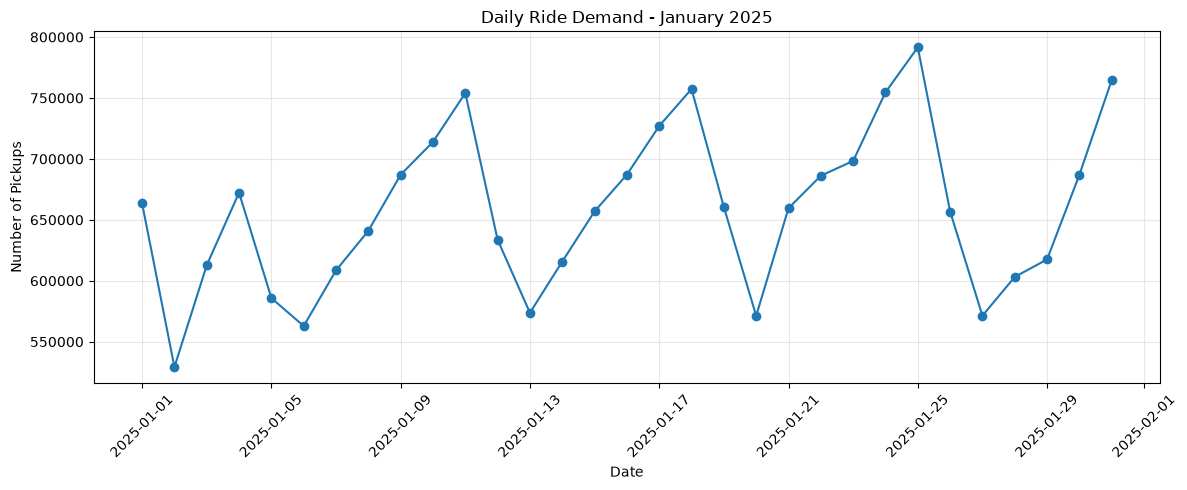

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    pd.to_datetime(daily_demand["date"]),
    daily_demand["demand"],
    marker="o"
)

plt.title("Daily Ride Demand - January 2025")
plt.xlabel("Date")
plt.ylabel("Number of Pickups")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

Insight: Ride demand varied considerably throughout January 2025. Average daily demand was approximately 658,222 pickups. The highest demand was recorded on January 25 with 791,550 pickups, while January 2 had the lowest demand with 529,213 pickups. The chart also shows a repeating pattern of peaks and declines, suggesting that demand may be influenced by the day of the week. Further day-of-week analysis is required to confirm this pattern.

In [8]:
average_daily = daily_demand["demand"].mean()

highest_day = daily_demand.loc[
    daily_demand["demand"].idxmax()
]

lowest_day = daily_demand.loc[
    daily_demand["demand"].idxmin()
]

print(f"Average daily demand: {average_daily:,.0f}")

print("\nHighest-demand day:")
print(highest_day)

print("\nLowest-demand day:")
print(lowest_day)

Average daily demand: 658,222

Highest-demand day:
date      2025-01-25
demand        791550
Name: 24, dtype: object

Lowest-demand day:
date      2025-01-02
demand        529213
Name: 1, dtype: object


average daily demand of each day of week

In [9]:
daily_with_day = (
    demand.groupby(
        ["date", "day_of_week", "day_of_week_num"],
        as_index=False
    )["demand"].sum()
)

weekday_demand = (
    daily_with_day.groupby(
        ["day_of_week", "day_of_week_num"],
        as_index=False
    )["demand"].mean()
)

weekday_demand = weekday_demand.sort_values(
    "day_of_week_num"
)

weekday_demand["demand"] = (
    weekday_demand["demand"].round().astype(int)
)

weekday_demand

,day_of_week,day_of_week_num,demand
1,Monday,0,569792
5,Tuesday,1,621746
6,Wednesday,2,653032
4,Thursday,3,657715
0,Friday,4,714597
2,Saturday,5,743812
3,Sunday,6,634194


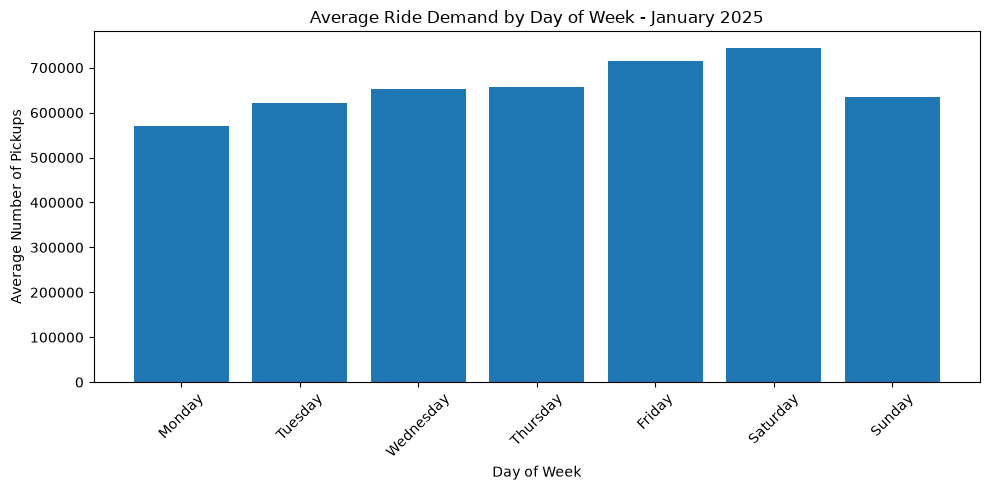

In [10]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_demand["day_of_week"],
    weekday_demand["demand"]
)

plt.title("Average Ride Demand by Day of Week - January 2025")
plt.xlabel("Day of Week")
plt.ylabel("Average Number of Pickups")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Insight: Average ride demand varies noticeably across the week. Saturday records the highest average daily demand at approximately 743,812 pickups, followed by Friday with 714,597. Monday has the lowest average demand at approximately 569,792 pickups. Demand generally increases toward the end of the working week, peaks on Saturday, and decreases again on Sunday. This indicates a clear day-of-week pattern in ride demand.

weekend vs weekday

In [11]:
daily_weekend = (
    demand.groupby(
        ["date", "is_weekend"],
        as_index=False
    )["demand"].sum()
)

weekend_comparison = (
    daily_weekend.groupby(
        "is_weekend",
        as_index=False
    )["demand"].mean()
)

weekend_comparison["day_type"] = weekend_comparison[
    "is_weekend"
].map({
    False: "Weekday",
    True: "Weekend"
})

weekend_comparison["demand"] = (
    weekend_comparison["demand"]
    .round()
    .astype(int)
)

weekend_comparison[
    ["day_type", "demand"]
]

,day_type,demand
0,Weekday,647516
1,Weekend,689003


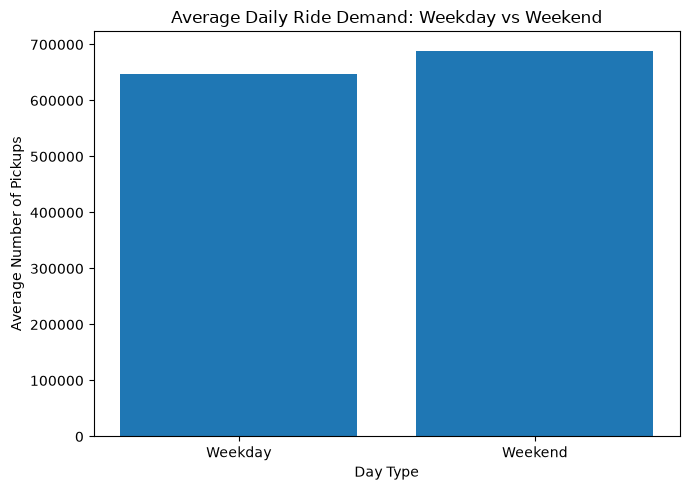

In [12]:
plt.figure(figsize=(7, 5))

plt.bar(
    weekend_comparison["day_type"],
    weekend_comparison["demand"]
)

plt.title("Average Daily Ride Demand: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Number of Pickups")

plt.tight_layout()
plt.show()

Insight: Average daily ride demand was approximately 689,003 pickups on weekends compared with 647,516 on weekdays, making weekend demand about 6.4% higher. However, the day-of-week analysis shows that this difference is mainly driven by the very high demand on Saturdays, while Sunday demand is considerably lower. Therefore, individual days provide more useful information than the weekend/weekday classification alone.

What hours have the highest demand?

In [13]:
hourly_demand = (
    demand.groupby("hour", as_index=False)["demand"]
          .sum()
)

# Average demand per calendar day at each hour
hourly_demand["avg_daily_demand"] = (
    hourly_demand["demand"] / demand["date"].nunique()
)

hourly_demand["avg_daily_demand"] = (
    hourly_demand["avg_daily_demand"]
    .round()
    .astype(int)
)

hourly_demand

,hour,demand,avg_daily_demand
0,0,682412,22013
1,1,477617,15407
2,2,352684,11377
3,3,289337,9333
4,4,300015,9678
5,5,359066,11583
6,6,575606,18568
7,7,896004,28903
8,8,1099840,35479
9,9,975495,31468


In [14]:
peak_hour = hourly_demand.loc[
    hourly_demand["avg_daily_demand"].idxmax()
]

lowest_hour = hourly_demand.loc[
    hourly_demand["avg_daily_demand"].idxmin()
]

print("Peak hour:")
print(peak_hour)

print("\nLowest-demand hour:")
print(lowest_hour)

Peak hour:
hour                     18
demand              1260372
avg_daily_demand      40657
Name: 18, dtype: int64

Lowest-demand hour:
hour                     3
demand              289337
avg_daily_demand      9333
Name: 3, dtype: int64


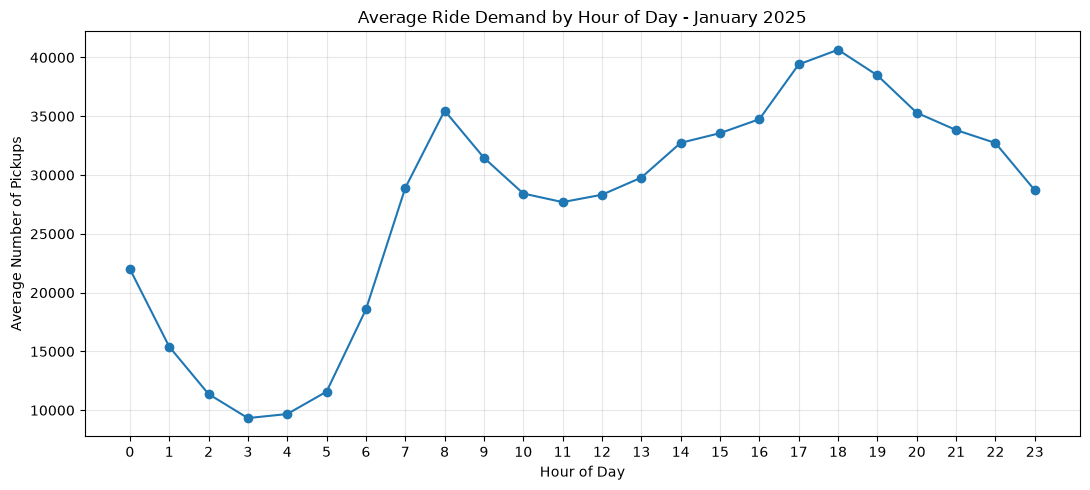

In [15]:
plt.figure(figsize=(11, 5))

plt.plot(
    hourly_demand["hour"],
    hourly_demand["avg_daily_demand"],
    marker="o"
)

plt.title("Average Ride Demand by Hour of Day - January 2025")
plt.xlabel("Hour of Day")
plt.ylabel("Average Number of Pickups")

plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

Insight: Ride demand shows a strong hourly pattern. The highest average demand occurs between 6:00 PM and 6:59 PM, with approximately 40,657 pickups per day, while the lowest demand occurs between 3:00 AM and 3:59 AM, with approximately 9,333 pickups. Peak-hour demand is more than four times the lowest-hour demand, indicating that time of day is an important factor in ride demand.

Weekday vs Weekend hourly pattern

In [16]:
hour_daytype = (
    demand.groupby(
        ["date", "hour", "is_weekend"],
        as_index=False
    )["demand"].sum()
)

hour_daytype_avg = (
    hour_daytype.groupby(
        ["hour", "is_weekend"],
        as_index=False
    )["demand"].mean()
)

hour_daytype_avg["day_type"] = (
    hour_daytype_avg["is_weekend"]
    .map({
        False: "Weekday",
        True: "Weekend"
    })
)

hour_daytype_avg["demand"] = (
    hour_daytype_avg["demand"].round()
)

hour_daytype_avg.head()

,hour,is_weekend,demand,day_type
0,0,False,17470.0,Weekday
1,0,True,35075.0,Weekend
2,1,False,11403.0,Weekday
3,1,True,26918.0,Weekend
4,2,False,8328.0,Weekday


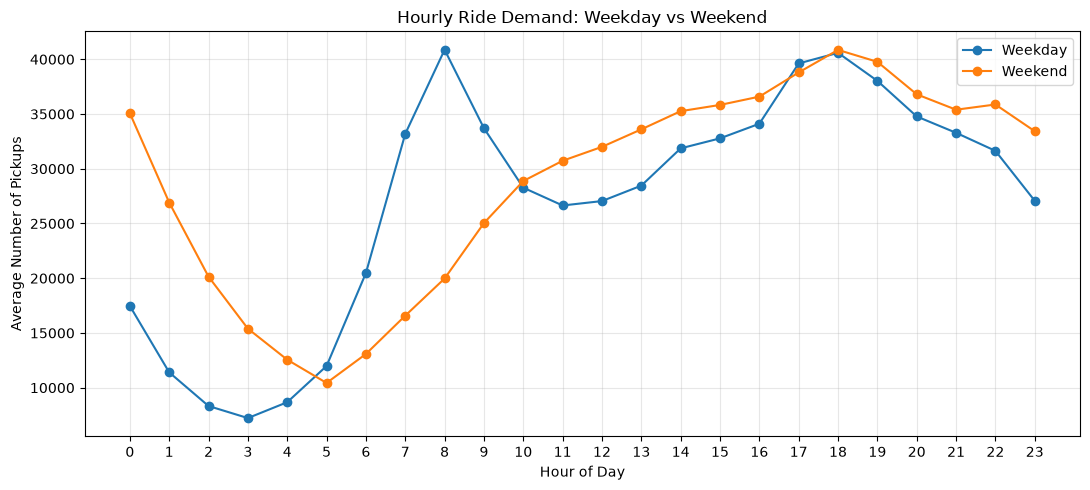

In [17]:
plt.figure(figsize=(11, 5))

for day_type in ["Weekday", "Weekend"]:
    subset = hour_daytype_avg[
        hour_daytype_avg["day_type"] == day_type
    ]

    plt.plot(
        subset["hour"],
        subset["demand"],
        marker="o",
        label=day_type
    )

plt.title("Hourly Ride Demand: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Average Number of Pickups")

plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

Insight: Weekday and weekend ride demand show distinctly different hourly patterns. On weekdays, demand rises sharply during the morning and reaches its highest level at 8:00 AM, with approximately 40,871 average pickups, followed by another high-demand period in the evening. In contrast, weekends do not show the same morning peak; demand generally increases throughout the day and reaches its maximum at 6:00 PM, with approximately 40,857 pickups. This indicates that both hour of day and day type are important for understanding and predicting ride demand

In [18]:
for day_type in ["Weekday", "Weekend"]:
    subset = hour_daytype_avg[
        hour_daytype_avg["day_type"] == day_type
    ]

    peak = subset.loc[
        subset["demand"].idxmax()
    ]

    print(
        f"{day_type} peak: "
        f"{int(peak['hour']):02d}:00 - "
        f"{peak['demand']:,.0f} average pickups"
    )

Weekday peak: 08:00 - 40,871 average pickups
Weekend peak: 18:00 - 40,857 average pickups


Which boroughs have the highest demand?

In [19]:
borough_demand = (
    demand.groupby("Borough", as_index=False)["demand"]
          .sum()
          .sort_values("demand", ascending=False)
)

borough_demand["percentage"] = (
    borough_demand["demand"]
    / borough_demand["demand"].sum()
    * 100
)

borough_demand["percentage"] = (
    borough_demand["percentage"].round(2)
)

borough_demand

,Borough,demand,percentage
3,Manhattan,7784756,38.15
1,Brooklyn,5458874,26.75
4,Queens,4260487,20.88
0,Bronx,2591558,12.70
5,Staten Island,309217,1.52
2,EWR,1,0.00


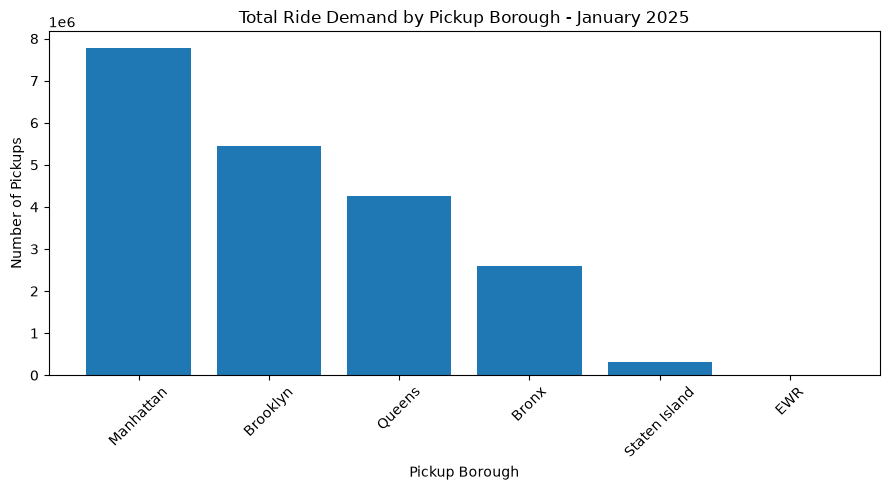

In [20]:
plt.figure(figsize=(9, 5))

plt.bar(
    borough_demand["Borough"],
    borough_demand["demand"]
)

plt.title("Total Ride Demand by Pickup Borough - January 2025")
plt.xlabel("Pickup Borough")
plt.ylabel("Number of Pickups")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Insight: Ride demand is strongly concentrated geographically. Manhattan recorded the highest pickup demand in January 2025 with approximately 7.78 million pickups, representing 38.15% of total modeled demand. Brooklyn accounted for 26.75% and Queens for 20.88%. Together, Manhattan, Brooklyn, and Queens represented approximately 85.78% of all pickups. Staten Island had considerably lower demand at 1.52%. EWR is a special taxi zone rather than an NYC borough and recorded only one pickup in the analyzed data.

Which pickup zones have the highest demand?

In [21]:
zone_demand = (
    demand.groupby(
        ["PULocationID", "Borough", "Zone"],
        as_index=False
    )["demand"]
    .sum()
    .sort_values("demand", ascending=False)
)

top_10_zones = zone_demand.head(10).copy()

top_10_zones["percentage"] = (
    top_10_zones["demand"]
    / demand["demand"].sum()
    * 100
).round(2)

top_10_zones

,PULocationID,Borough,Zone,demand,percentage
131,132,Queens,JFK Airport,366536,1.80
137,138,Queens,LaGuardia Airport,361220,1.77
60,61,Brooklyn,Crown Heights North,265393,1.30
78,79,Manhattan,East Village,255992,1.25
229,230,Manhattan,Times Sq/Theatre District,245839,1.20
160,161,Manhattan,Midtown Center,239287,1.17
230,231,Manhattan,TriBeCa/Civic Center,229707,1.13
233,234,Manhattan,Union Sq,221311,1.08
36,37,Brooklyn,Bushwick South,218353,1.07
75,76,Brooklyn,East New York,218048,1.07


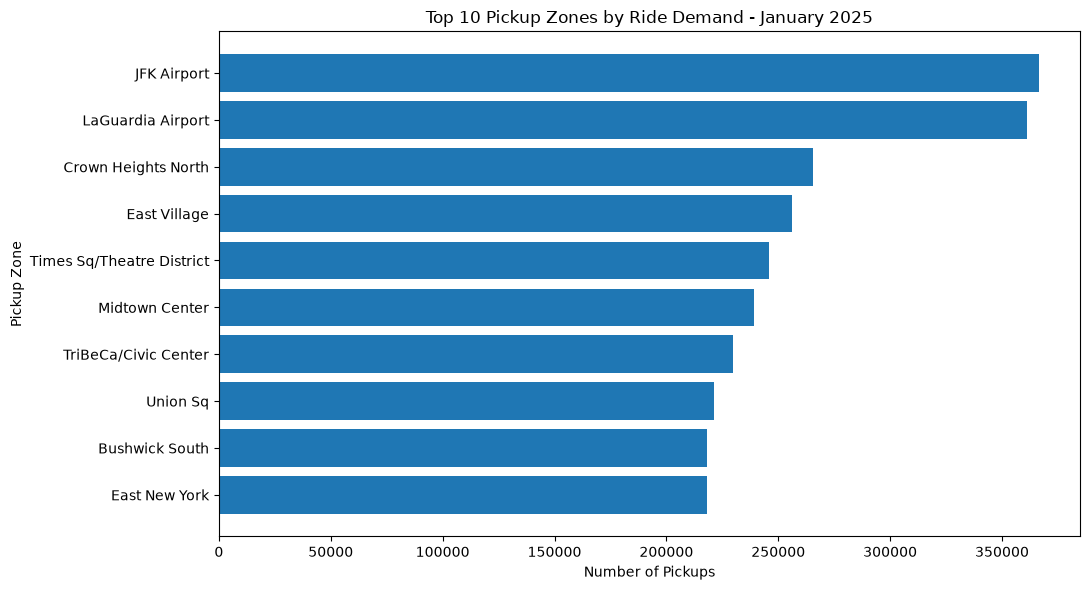

In [22]:
plt.figure(figsize=(11, 6))

plt.barh(
    top_10_zones["Zone"],
    top_10_zones["demand"]
)

plt.title("Top 10 Pickup Zones by Ride Demand - January 2025")
plt.xlabel("Number of Pickups")
plt.ylabel("Pickup Zone")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

Insight: JFK Airport and LaGuardia Airport recorded the highest pickup demand among individual taxi zones, indicating particularly strong ride activity around major airports. Other high-demand zones include Crown Heights North, East Village, Times Sq/Theatre District, and Midtown Center. However, the top 10 pickup zones together account for only 12.85% of total ride demand, showing that overall demand is distributed across many locations rather than being dominated by only a small number of zones.

In [23]:
top_10_share = (
    top_10_zones["demand"].sum()
    / demand["demand"].sum()
    * 100
)

print(
    f"Top 10 zones account for "
    f"{top_10_share:.2f}% of total demand."
)

Top 10 zones account for 12.85% of total demand.


###Trip analytics

In [24]:
import pyarrow.parquet as pq

trip_path = "../data/processed/trips_analytics_2025_01.parquet"

trip_file = pq.ParquetFile(trip_path)

print("Total trip records:", f"{trip_file.metadata.num_rows:,}")
print("Columns:", trip_file.metadata.num_columns)

Total trip records: 20,405,666
Columns: 21


In [25]:
sample_parts = []

for batch in trip_file.iter_batches(
    batch_size=500_000,
    columns=[
        "pickup_datetime",
        "PULocationID",
        "DOLocationID",
        "trip_miles",
        "trip_time",
        "trip_duration_min",
        "base_passenger_fare",
        "tips",
        "driver_pay",
        "valid_distance",
        "valid_duration",
        "valid_fare"
    ]
):
    batch_df = batch.to_pandas()

    # Approximately 2% sample from every batch
    sample_parts.append(
        batch_df.sample(
            frac=0.02,
            random_state=42
        )
    )

trip_sample = pd.concat(
    sample_parts,
    ignore_index=True
)

print("Sample rows:", f"{len(trip_sample):,}")
trip_sample.head()

Sample rows: 408,113


,pickup_datetime,PULocationID,DOLocationID,trip_miles,trip_time,trip_duration_min,base_passenger_fare,tips,driver_pay,valid_distance,valid_duration,valid_fare
0,2025-01-01 01:21:28,221,4,15.62,1627,27.116667,74.88,0.0,61.74,True,True,True
1,2025-01-01 03:38:03,81,263,12.34,1159,19.316667,30.98,0.0,29.54,True,True,True
2,2025-01-01 02:00:25,182,78,1.53,469,7.816667,12.51,0.0,10.92,True,True,True
3,2025-01-01 02:03:39,7,129,2.51,1038,17.300000,18.50,0.0,19.14,True,True,True
4,2025-01-01 13:26:13,87,265,4.37,1174,19.566667,36.23,0.0,21.73,True,True,True


How far and how long are typical rides?

In [26]:
valid_trips = trip_sample[
    (trip_sample["valid_distance"]) &
    (trip_sample["valid_duration"])
].copy()

print("Sample records:", f"{len(trip_sample):,}")
print("Valid distance & duration records:", f"{len(valid_trips):,}")

Sample records: 408,113
Valid distance & duration records: 408,060


In [27]:
trip_stats = valid_trips[
    ["trip_miles", "trip_duration_min"]
].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

trip_stats

,trip_miles,trip_duration_min
count,408060.000000,408060.000000
mean,4.857007,18.224612
std,5.716640,12.455261
min,0.007000,0.016667
25%,1.479000,9.400000
50%,2.840000,15.066667
75%,6.050000,23.533333
90%,11.180000,34.316667
95%,16.060000,42.433333
99%,26.445870,61.166667


In [28]:
print("Distance:")
print(f"Median: {valid_trips['trip_miles'].median():.2f} miles")
print(f"Mean: {valid_trips['trip_miles'].mean():.2f} miles")
print(f"95th percentile: {valid_trips['trip_miles'].quantile(0.95):.2f} miles")
print(f"99th percentile: {valid_trips['trip_miles'].quantile(0.99):.2f} miles")

print("\nDuration:")
print(f"Median: {valid_trips['trip_duration_min'].median():.2f} minutes")
print(f"Mean: {valid_trips['trip_duration_min'].mean():.2f} minutes")
print(f"95th percentile: {valid_trips['trip_duration_min'].quantile(0.95):.2f} minutes")
print(f"99th percentile: {valid_trips['trip_duration_min'].quantile(0.99):.2f} minutes")

Distance:
Median: 2.84 miles
Mean: 4.86 miles
95th percentile: 16.06 miles
99th percentile: 26.45 miles

Duration:
Median: 15.07 minutes
Mean: 18.22 minutes
95th percentile: 42.43 minutes
99th percentile: 61.17 minutes


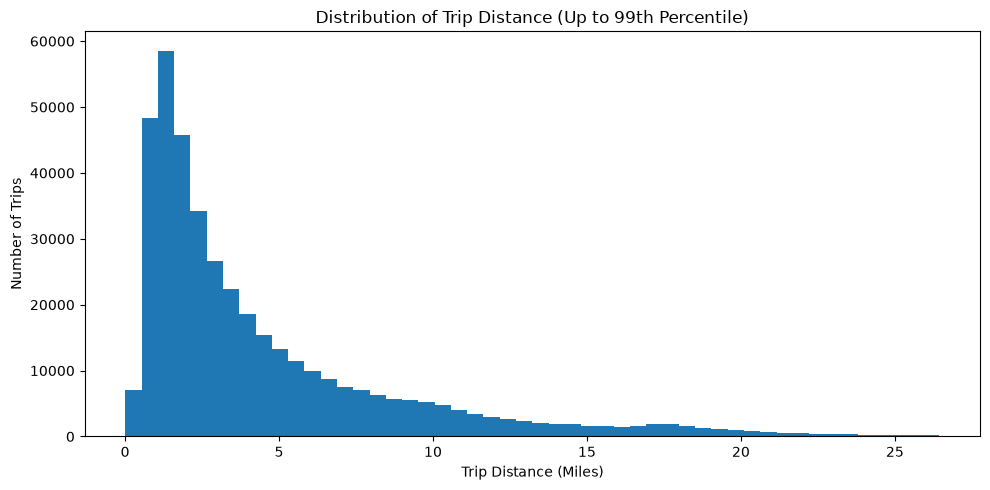

In [29]:
distance_99 = valid_trips["trip_miles"].quantile(0.99)

plt.figure(figsize=(10, 5))
plt.hist(
    valid_trips.loc[
        valid_trips["trip_miles"] <= distance_99,
        "trip_miles"
    ],
    bins=50
)

plt.title("Distribution of Trip Distance (Up to 99th Percentile)")
plt.xlabel("Trip Distance (Miles)")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

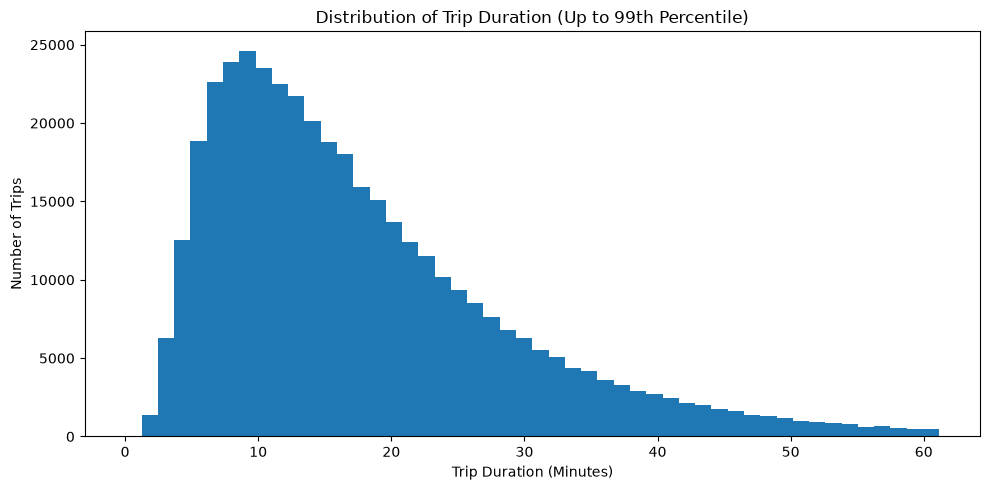

In [30]:
duration_99 = valid_trips["trip_duration_min"].quantile(0.99)

plt.figure(figsize=(10, 5))
plt.hist(
    valid_trips.loc[
        valid_trips["trip_duration_min"] <= duration_99,
        "trip_duration_min"
    ],
    bins=50
)

plt.title("Distribution of Trip Duration (Up to 99th Percentile)")
plt.xlabel("Trip Duration (Minutes)")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

Insight: Trip distance and duration are both right-skewed. The median trip distance was 2.84 miles compared with a mean of 4.86 miles, indicating that most trips were relatively short while a smaller number of long-distance trips increased the average. Similarly, the median trip duration was approximately 15.07 minutes, compared with a mean of 18.22 minutes. About 95% of sampled valid trips were within 16.06 miles and 42.43 minutes. Therefore, median values provide a more representative description of a typical trip than mean values.

Distance vs Fare

In [31]:
fare_trips = trip_sample[
    (trip_sample["valid_distance"]) &
    (trip_sample["valid_fare"])
].copy()

print("Valid distance & fare records:", f"{len(fare_trips):,}")

Valid distance & fare records: 408,010


In [32]:
pearson_corr = fare_trips[
    ["trip_miles", "base_passenger_fare"]
].corr().iloc[0, 1]

print(
    f"Correlation between trip distance and base fare: "
    f"{pearson_corr:.3f}"
)

Correlation between trip distance and base fare: 0.857


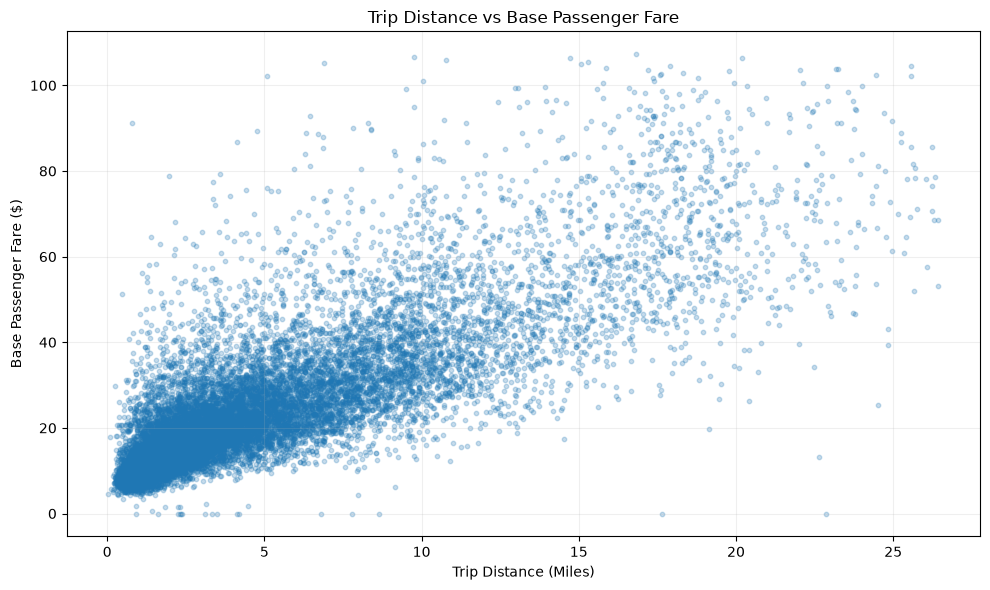

In [33]:
scatter_sample = fare_trips.sample(
    n=min(20_000, len(fare_trips)),
    random_state=42
)

distance_limit = fare_trips["trip_miles"].quantile(0.99)
fare_limit = fare_trips["base_passenger_fare"].quantile(0.99)

scatter_plot_data = scatter_sample[
    (scatter_sample["trip_miles"] <= distance_limit) &
    (scatter_sample["base_passenger_fare"] <= fare_limit)
]

plt.figure(figsize=(10, 6))

plt.scatter(
    scatter_plot_data["trip_miles"],
    scatter_plot_data["base_passenger_fare"],
    alpha=0.25,
    s=10
)

plt.title("Trip Distance vs Base Passenger Fare")
plt.xlabel("Trip Distance (Miles)")
plt.ylabel("Base Passenger Fare ($)")
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

Insight: Trip distance has a strong positive relationship with base passenger fare, with a Pearson correlation coefficient of 0.857. The scatter plot shows that longer trips generally have higher passenger fares. However, fares vary even among trips of similar distances, indicating that distance is not the only factor associated with fare. This analysis demonstrates association rather than causation.

Fare, Tips & Driver Pay

In [34]:
financial_trips = trip_sample[
    trip_sample["valid_fare"]
].copy()

financial_stats = financial_trips[
    ["base_passenger_fare", "tips", "driver_pay"]
].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

financial_stats

,base_passenger_fare,tips,driver_pay
count,408063.000000,408063.000000,408063.000000
mean,24.298191,1.044648,18.656691
std,21.016904,3.157800,15.916857
min,0.000000,0.000000,-19.160000
25%,11.640000,0.000000,8.360000
50%,18.020000,0.000000,13.970000
75%,28.975000,0.000000,23.460000
90%,46.330000,3.940000,37.020000
95%,62.010000,6.279000,48.300000
99%,107.383800,15.000000,76.810000


In [35]:
print("BASE PASSENGER FARE")
print(f"Mean: ${financial_trips['base_passenger_fare'].mean():.2f}")
print(f"Median: ${financial_trips['base_passenger_fare'].median():.2f}")

print("\nTIPS")
print(f"Mean: ${financial_trips['tips'].mean():.2f}")
print(f"Median: ${financial_trips['tips'].median():.2f}")

tip_rate = (financial_trips["tips"] > 0).mean() * 100
print(f"Trips with a recorded tip: {tip_rate:.2f}%")

print("\nDRIVER PAY")
print(f"Mean: ${financial_trips['driver_pay'].mean():.2f}")
print(f"Median: ${financial_trips['driver_pay'].median():.2f}")

BASE PASSENGER FARE
Mean: $24.30
Median: $18.02

TIPS
Mean: $1.04
Median: $0.00
Trips with a recorded tip: 18.43%

DRIVER PAY
Mean: $18.66
Median: $13.97


Insight: In the sampled valid-fare trips, the median base passenger fare was $18.02, while the mean was $24.30, indicating that higher-fare trips raise the overall average. The median recorded tip was $0.00 and approximately 18.43% of trips had a positive recorded tip. Driver pay had a median of $13.97 and a mean of $18.66. The presence of negative driver-pay values requires separate investigation before drawing conclusions about driver earnings.

Tip Behaviour

In [36]:
tip_analysis = financial_trips[
    financial_trips["valid_distance"]
].copy()

tip_analysis["distance_group"] = pd.cut(
    tip_analysis["trip_miles"],
    bins=[0, 2, 5, 10, 20, float("inf")],
    labels=[
        "0–2 miles",
        "2–5 miles",
        "5–10 miles",
        "10–20 miles",
        "20+ miles"
    ],
    include_lowest=True
)

tip_by_distance = (
    tip_analysis.groupby(
        "distance_group",
        observed=True
    )
    .agg(
        trips=("tips", "size"),
        average_tip=("tips", "mean"),
        median_tip=("tips", "median"),
        tipped_trips=("tips", lambda x: (x > 0).sum())
    )
    .reset_index()
)

tip_by_distance["tip_rate"] = (
    tip_by_distance["tipped_trips"]
    / tip_by_distance["trips"]
    * 100
)

tip_by_distance["average_tip"] = tip_by_distance["average_tip"].round(2)
tip_by_distance["median_tip"] = tip_by_distance["median_tip"].round(2)
tip_by_distance["tip_rate"] = tip_by_distance["tip_rate"].round(2)

tip_by_distance

,distance_group,trips,average_tip,median_tip,tipped_trips,tip_rate
0,0–2 miles,150551,0.53,0.0,25962,17.24
1,2–5 miles,132594,0.75,0.0,23013,17.36
2,5–10 miles,74318,1.30,0.0,14289,19.23
3,10–20 miles,41310,2.47,0.0,9406,22.77
4,20+ miles,9237,5.32,0.0,2549,27.60


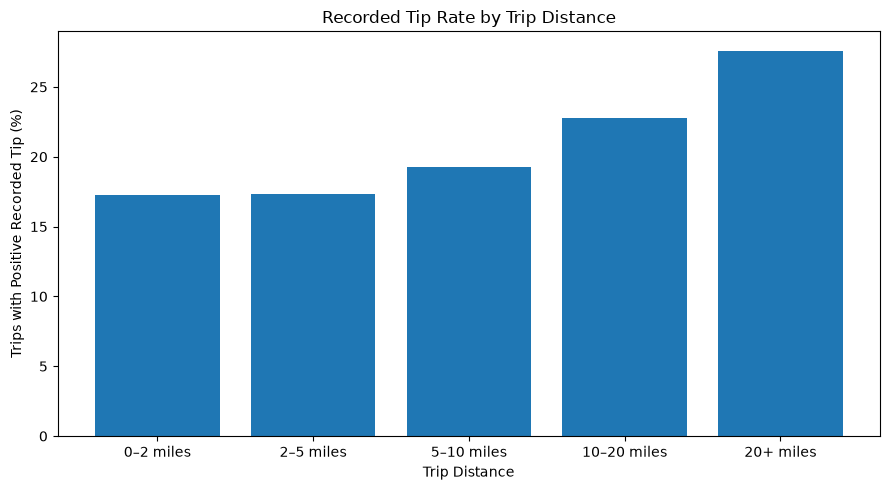

In [37]:
plt.figure(figsize=(9, 5))

plt.bar(
    tip_by_distance["distance_group"].astype(str),
    tip_by_distance["tip_rate"]
)

plt.title("Recorded Tip Rate by Trip Distance")
plt.xlabel("Trip Distance")
plt.ylabel("Trips with Positive Recorded Tip (%)")

plt.tight_layout()
plt.show()

Insight: The proportion of trips with a positive recorded tip generally increases with trip distance. Approximately 17.24% of trips up to 2 miles had a positive recorded tip, compared with 27.60% of trips over 20 miles. Average recorded tip amount also increased from $0.53 for the shortest-distance group to $5.32 for trips over 20 miles. However, the median tip remained $0 across all distance groups, showing that zero recorded tips remained common. These results indicate an association between trip distance and recorded tipping behaviour, but do not establish causation.

##Full-dataset financial KPIs

In [38]:
total_rows = 0
valid_fare_rows = 0

total_base_fare = 0.0
total_tips = 0.0
total_driver_pay = 0.0

positive_tip_trips = 0

for batch in trip_file.iter_batches(
    batch_size=500_000,
    columns=[
        "base_passenger_fare",
        "tips",
        "driver_pay",
        "valid_fare"
    ]
):
    df_batch = batch.to_pandas()

    total_rows += len(df_batch)

    valid = df_batch[df_batch["valid_fare"]]

    valid_fare_rows += len(valid)

    total_base_fare += valid["base_passenger_fare"].sum()
    total_tips += valid["tips"].sum()
    total_driver_pay += valid["driver_pay"].sum()

    positive_tip_trips += (valid["tips"] > 0).sum()

print("FULL JANUARY FINANCIAL SUMMARY")
print("--------------------------------")

print(f"Total trip records: {total_rows:,}")
print(f"Valid-fare records: {valid_fare_rows:,}")

print(f"\nTotal base passenger fare: ${total_base_fare:,.2f}")
print(f"Average base passenger fare: ${total_base_fare / valid_fare_rows:,.2f}")

print(f"\nTotal recorded tips: ${total_tips:,.2f}")
print(f"Average recorded tip: ${total_tips / valid_fare_rows:,.2f}")

print(f"\nTrips with positive recorded tip: {positive_tip_trips:,}")
print(
    f"Positive recorded-tip rate: "
    f"{positive_tip_trips / valid_fare_rows * 100:.2f}%"
)

print(f"\nTotal driver pay: ${total_driver_pay:,.2f}")
print(f"Average driver pay: ${total_driver_pay / valid_fare_rows:,.2f}")

FULL JANUARY FINANCIAL SUMMARY
--------------------------------
Total trip records: 20,405,666
Valid-fare records: 20,403,239

Total base passenger fare: $495,163,870.61
Average base passenger fare: $24.27

Total recorded tips: $21,246,214.81
Average recorded tip: $1.04

Trips with positive recorded tip: 3,762,948
Positive recorded-tip rate: 18.44%

Total driver pay: $380,551,464.16
Average driver pay: $18.65


Insight: Across the full January 2025 dataset, 20.40 million trips were analyzed, of which 20.40 million had valid base-fare values. The total base passenger fare recorded was approximately $495.16 million, with an average of $24.27 per valid-fare trip. Recorded tips totaled approximately $21.25 million, and 18.44% of valid-fare trips contained a positive recorded tip. The driver-pay field totaled approximately $380.55 million, with an average of $18.65 per valid-fare trip. These values describe recorded trip-level financial measures and should not be interpreted directly as company revenue or profit.

#Demand variability by zone     (cv=coefficient of variation)

In [39]:
zone_variability = (
    demand.groupby(
        ["PULocationID", "Borough", "Zone"],
        as_index=False
    )
    .agg(
        mean_hourly_demand=("demand", "mean"),
        std_hourly_demand=("demand", "std"),
        max_hourly_demand=("demand", "max"),
        zero_demand_hours=("demand", lambda x: (x == 0).sum())
    )
)

zone_variability["cv"] = (
    zone_variability["std_hourly_demand"]
    / zone_variability["mean_hourly_demand"]
)

zone_variability.sort_values(
    "mean_hourly_demand",
    ascending=False
).head(10)

,PULocationID,Borough,Zone,mean_hourly_demand,std_hourly_demand,max_hourly_demand,zero_demand_hours,cv
131,132,Queens,JFK Airport,492.655914,268.228800,1281,0,0.544455
137,138,Queens,LaGuardia Airport,485.510753,344.043805,1388,3,0.708622
60,61,Brooklyn,Crown Heights North,356.711022,159.822129,1005,0,0.448044
78,79,Manhattan,East Village,344.075269,262.205574,1346,0,0.762059
229,230,Manhattan,Times Sq/Theatre District,330.428763,192.499533,1084,0,0.582575
160,161,Manhattan,Midtown Center,321.622312,254.412074,1183,0,0.791027
230,231,Manhattan,TriBeCa/Civic Center,308.745968,182.770222,827,0,0.591976
233,234,Manhattan,Union Sq,297.461022,191.413714,805,0,0.643492
36,37,Brooklyn,Bushwick South,293.485215,162.016482,1535,0,0.552043
75,76,Brooklyn,East New York,293.075269,125.807078,657,0,0.429265


In [40]:
zone_variability["zero_hour_percentage"] = (
    zone_variability["zero_demand_hours"] / 744 * 100
)

print("Zones with at least one zero-demand hour:",
      (zone_variability["zero_demand_hours"] > 0).sum())

print("Zones with no zero-demand hours:",
      (zone_variability["zero_demand_hours"] == 0).sum())

display(
    zone_variability.sort_values(
        "zero_hour_percentage",
        ascending=False
    ).head(10)
)

Zones with at least one zero-demand hour: 58
Zones with no zero-demand hours: 205


,PULocationID,Borough,Zone,mean_hourly_demand,std_hourly_demand,max_hourly_demand,zero_demand_hours,cv,zero_hour_percentage
103,104,Manhattan,Governor's Island/Ellis Island/Liberty Island,0.000000,0.000000,0,744,NaN,100.000000
102,103,Manhattan,Governor's Island/Ellis Island/Liberty Island,0.000000,0.000000,0,744,NaN,100.000000
0,1,EWR,Newark Airport,0.001344,0.036662,1,743,27.276363,99.865591
104,105,Manhattan,Governor's Island/Ellis Island/Liberty Island,0.005376,0.073175,1,740,13.610621,99.462366
198,199,Bronx,Rikers Island,0.005376,0.073175,1,740,13.610621,99.462366
109,110,Staten Island,Great Kills Park,0.025538,0.157857,1,725,6.181363,97.446237
1,2,Queens,Jamaica Bay,0.034946,0.190951,2,719,5.464128,96.639785
252,253,Queens,Willets Point,0.537634,0.922973,5,492,1.716730,66.129032
7,8,Queens,Astoria Park,0.505376,0.773013,5,461,1.529578,61.962366
98,99,Staten Island,Freshkills Park,0.588710,0.846293,7,430,1.437538,57.795699


Insight: Demand behaviour differs substantially across pickup zones. Major zones such as JFK Airport, LaGuardia Airport and several Manhattan and Brooklyn zones maintain high average hourly demand, although their variability differs considerably. Of the 263 modeled zones, 205 recorded demand during every hour of January, while 58 contained at least one zero-demand hour. Several special or very low-activity zones were extremely sparse, including zones with almost no recorded pickups. This variation is important for demand prediction because a single model must account for both high-volume and sparse-demand locations.

Demand distribution

In [41]:
print(demand["demand"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
))

print(
    "\nZero-demand percentage:",
    f"{(demand['demand'].eq(0).mean() * 100):.2f}%"
)

count    195672.000000
mean        104.281108
std         117.007058
min           0.000000
50%          69.000000
75%         145.000000
90%         247.000000
95%         320.000000
99%         548.000000
max        1535.000000
Name: demand, dtype: float64

Zero-demand percentage: 4.66%


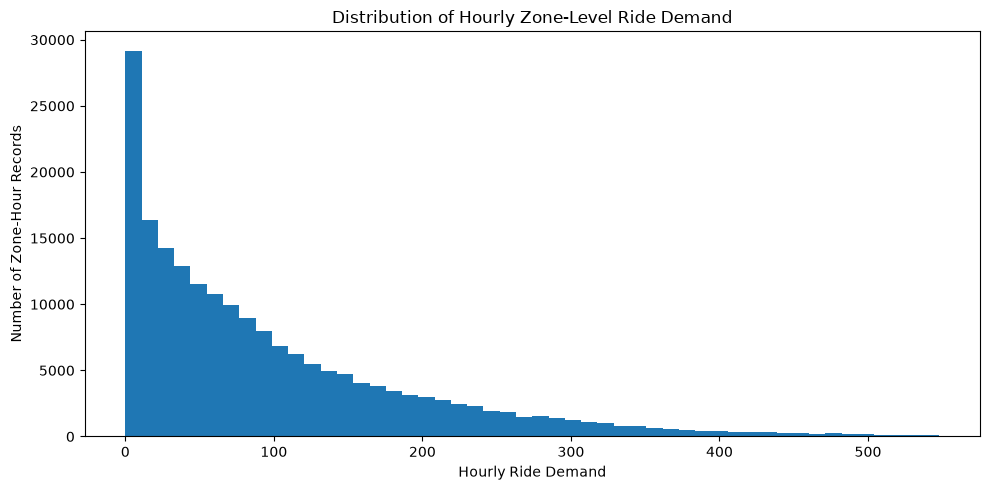

In [42]:
demand_99 = demand["demand"].quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    demand.loc[
        demand["demand"] <= demand_99,
        "demand"
    ],
    bins=50
)

plt.title("Distribution of Hourly Zone-Level Ride Demand")
plt.xlabel("Hourly Ride Demand")
plt.ylabel("Number of Zone-Hour Records")

plt.tight_layout()
plt.show()